# 🤖 Project 1: AI-Powered Task Management System
## Week 1: Data Collection, EDA & NLP Preprocessing

In [8]:
# Install required libraries
!pip install nltk pandas numpy matplotlib seaborn wordcloud

# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')   # ← add this line
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

print("✅ All libraries imported successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


✅ All libraries imported successfully!


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [3]:
# ============================================================
# CREATING OUR TASK DATASET (Synthetic but Realistic)
# ============================================================

import pandas as pd
import numpy as np

np.random.seed(42)

descriptions = [
    "Fix critical login bug causing users to be locked out",
    "Design new homepage UI with modern layout",
    "Write unit tests for payment module",
    "Deploy application to AWS production server",
    "Update API documentation for v2 endpoints",
    "Investigate memory leak in background service",
    "Create onboarding email sequence for new users",
    "Optimize slow database queries on user table",
    "Implement two-factor authentication feature",
    "Review and merge pull requests from team",
    "Set up CI/CD pipeline for automated testing",
    "Fix broken image links on product pages",
    "Conduct user interviews for feedback collection",
    "Refactor legacy authentication code",
    "Add search functionality to dashboard",
    "Resolve payment gateway timeout errors",
    "Create monthly performance report",
    "Train new team member on codebase",
    "Update SSL certificates before expiry",
    "Build data export feature as CSV download",
    "Fix navigation menu on mobile devices",
    "Write technical specification document",
    "Analyze user drop-off in onboarding funnel",
    "Migrate database from MySQL to PostgreSQL",
    "Add dark mode support to the application",
    "Fix security vulnerability in file upload",
    "Create admin panel for user management",
    "Set up monitoring and alerting with Grafana",
    "Improve page load speed by compressing assets",
    "Implement role-based access control system",
    "Write blog post about new product features",
    "Fix crash in iOS app on startup",
    "Build REST API for mobile application",
    "Conduct code review for new developer",
    "Update privacy policy and terms of service",
    "Implement email notification system",
    "Debug failing automated test cases",
    "Design database schema for new module",
    "Integrate third-party payment processor",
    "Create user activity dashboard with charts",
    "Fix timezone issue in scheduling feature",
    "Write end-to-end test scenarios",
    "Perform load testing on production server",
    "Add multi-language support to application",
    "Fix broken CSV import functionality",
    "Create backup and recovery procedure",
    "Implement lazy loading for images",
    "Review security audit findings",
    "Build recommendation engine for products",
    "Fix logout not working on Safari browser",
    "Update dependencies to latest versions",
    "Design mockup for new checkout flow",
    "Investigate high CPU usage on server",
    "Create API rate limiting mechanism",
    "Fix date picker not working on Firefox",
    "Implement webhook for payment events",
    "Write user manual for admin features",
    "Optimize image compression pipeline",
    "Fix email not sending in production",
    "Build analytics tracking integration",
    "Resolve merge conflict in main branch",
    "Create data validation for input forms",
    "Set up staging environment for QA",
    "Fix wrong calculations in billing module",
    "Implement password reset functionality",
    "Write migration scripts for database upgrade",
    "Add export to PDF feature for reports",
    "Fix broken links in help documentation",
    "Build chat support widget integration",
    "Conduct sprint retrospective meeting",
    "Fix session timeout happening too early",
    "Create automated email reports",
    "Investigate data inconsistency in reports",
    "Implement audit logging for user actions",
    "Fix 404 error on product detail page",
    "Design email templates for campaigns",
    "Build inventory management module",
    "Fix incorrect tax calculation in checkout",
    "Write API integration guide for partners",
    "Set up Redis caching for performance",
    "Fix broken pagination on search results",
    "Implement GDPR data deletion feature",
    "Review and update test documentation",
    "Build notification preferences settings",
    "Fix video not playing on mobile devices",
    "Conduct performance review meetings",
    "Implement social login with Google OAuth",
    "Fix slow report generation taking too long",
    "Create sample data for demo environment",
    "Build subscription billing management",
    "Fix incorrect user permissions on dashboard",
    "Implement file compression before upload",
    "Write changelog for version 2.0 release",
    "Fix map not loading in location feature",
    "Build automated invoice generation system",
    "Conduct security penetration testing",
    "Fix broken filter on transaction history",
    "Implement real-time notifications using WebSocket",
    "Fix incorrect sorting in leaderboard",
    "Write deployment runbook for production",
    "Build customer feedback collection form",
    "Fix calendar sync not working with Google"
]

categories = [
    'Bug','Design','Testing','Deployment','Documentation',
    'Bug','Marketing','Optimization','Feature','Management',
    'DevOps','Bug','Research','Refactoring','Feature',
    'Bug','Reporting','Management','DevOps','Feature',
    'Bug','Documentation','Research','Migration','Feature',
    'Security','Feature','DevOps','Optimization','Feature',
    'Marketing','Bug','Feature','Management','Documentation',
    'Feature','Testing','Design','Integration','Feature',
    'Bug','Testing','Testing','Feature','Bug',
    'DevOps','Optimization','Security','Feature','Bug',
    'DevOps','Design','Bug','Feature','Bug',
    'Integration','Documentation','Optimization','Bug','Integration',
    'Bug','Feature','DevOps','Bug','Feature',
    'Migration','Feature','Documentation','Integration','Management',
    'Bug','Reporting','Bug','Security','Bug',
    'Design','Feature','Bug','Documentation','DevOps',
    'Bug','Security','Documentation','Feature','Bug',
    'Management','Feature','Bug','Feature','Bug',
    'Feature','Documentation','Bug','Feature','Security',
    'Bug','Feature','Bug','Documentation','Feature','Bug'
]

priorities = [
    'High','Medium','Low','High','Low',
    'High','Medium','High','High','Medium',
    'Medium','Low','Medium','Medium','High',
    'High','Low','Low','High','Medium',
    'Low','Medium','Medium','High','Low',
    'High','Medium','Medium','Medium','High',
    'Low','High','High','Low','Low',
    'Medium','Medium','Medium','High','Medium',
    'Medium','Medium','High','Medium','Medium',
    'High','Medium','High','High','Medium',
    'Low','Medium','High','High','Low',
    'Medium','Low','Medium','High','Medium',
    'Medium','Medium','Low','High','Medium',
    'Medium','Low','Medium','Low','Medium',
    'High','Low','High','High','Low',
    'Medium','High','Low','Medium','Medium',
    'Medium','High','Medium','High','Medium',
    'High','Low','High','High','Medium',
    'High','Low','High','Medium','High',
    'Medium','Medium','Medium','Low','High','Medium'
]

# ✅ Verify all lists are the same length before creating DataFrame
print(f"Descriptions: {len(descriptions)}")
print(f"Categories  : {len(categories)}")
print(f"Priorities  : {len(priorities)}")

# Trim all to the same length just in case
min_len = min(len(descriptions), len(categories), len(priorities))

df = pd.DataFrame({
    'task_id'       : range(1, min_len + 1),
    'description'   : descriptions[:min_len],
    'category'      : categories[:min_len],
    'priority'      : priorities[:min_len],
    'assignee'      : np.random.choice(['Alice','Bob','Charlie','Diana','Eve'], min_len),
    'deadline_days' : np.random.randint(1, 30, min_len),
    'workload_score': np.random.randint(1, 10, min_len)
})

print(f"\n✅ Dataset created successfully! Shape: {df.shape}")
df.head(10)

Descriptions: 102
Categories  : 101
Priorities  : 101

✅ Dataset created successfully! Shape: (101, 7)


,task_id,description,category,priority,assignee,deadline_days,workload_score
0,1,Fix critical login bug causing users to be loc...,Bug,High,Diana,7,1
1,2,Design new homepage UI with modern layout,Design,Medium,Eve,9,4
2,3,Write unit tests for payment module,Testing,Low,Charlie,8,7
3,4,Deploy application to AWS production server,Deployment,High,Eve,12,2
4,5,Update API documentation for v2 endpoints,Documentation,Low,Eve,2,3
5,6,Investigate memory leak in background service,Bug,High,Bob,1,1
6,7,Create onboarding email sequence for new users,Marketing,Medium,Charlie,16,5
7,8,Optimize slow database queries on user table,Optimization,High,Charlie,23,1
8,9,Implement two-factor authentication feature,Feature,High,Charlie,23,8
9,10,Review and merge pull requests from team,Management,Medium,Eve,24,1


In [4]:
# ============================================================
# EDA - EXPLORATORY DATA ANALYSIS
# ============================================================

print("📊 DATASET OVERVIEW")
print("="*50)
print(f"Total Tasks: {len(df)}")
print(f"\nColumn Info:")
print(df.dtypes)
print(f"\nMissing Values:")
print(df.isnull().sum())
print(f"\nBasic Statistics:")
df[['deadline_days','workload_score']].describe()

📊 DATASET OVERVIEW
Total Tasks: 101

Column Info:
task_id            int64
description       object
category          object
priority          object
assignee          object
deadline_days      int64
workload_score     int64
dtype: object

Missing Values:
task_id           0
description       0
category          0
priority          0
assignee          0
deadline_days     0
workload_score    0
dtype: int64

Basic Statistics:


,deadline_days,workload_score
count,101.000000,101.000000
mean,14.524752,4.554455
std,8.849400,2.670113
min,1.000000,1.000000
25%,7.000000,2.000000
50%,13.000000,4.000000
75%,23.000000,7.000000
max,29.000000,9.000000


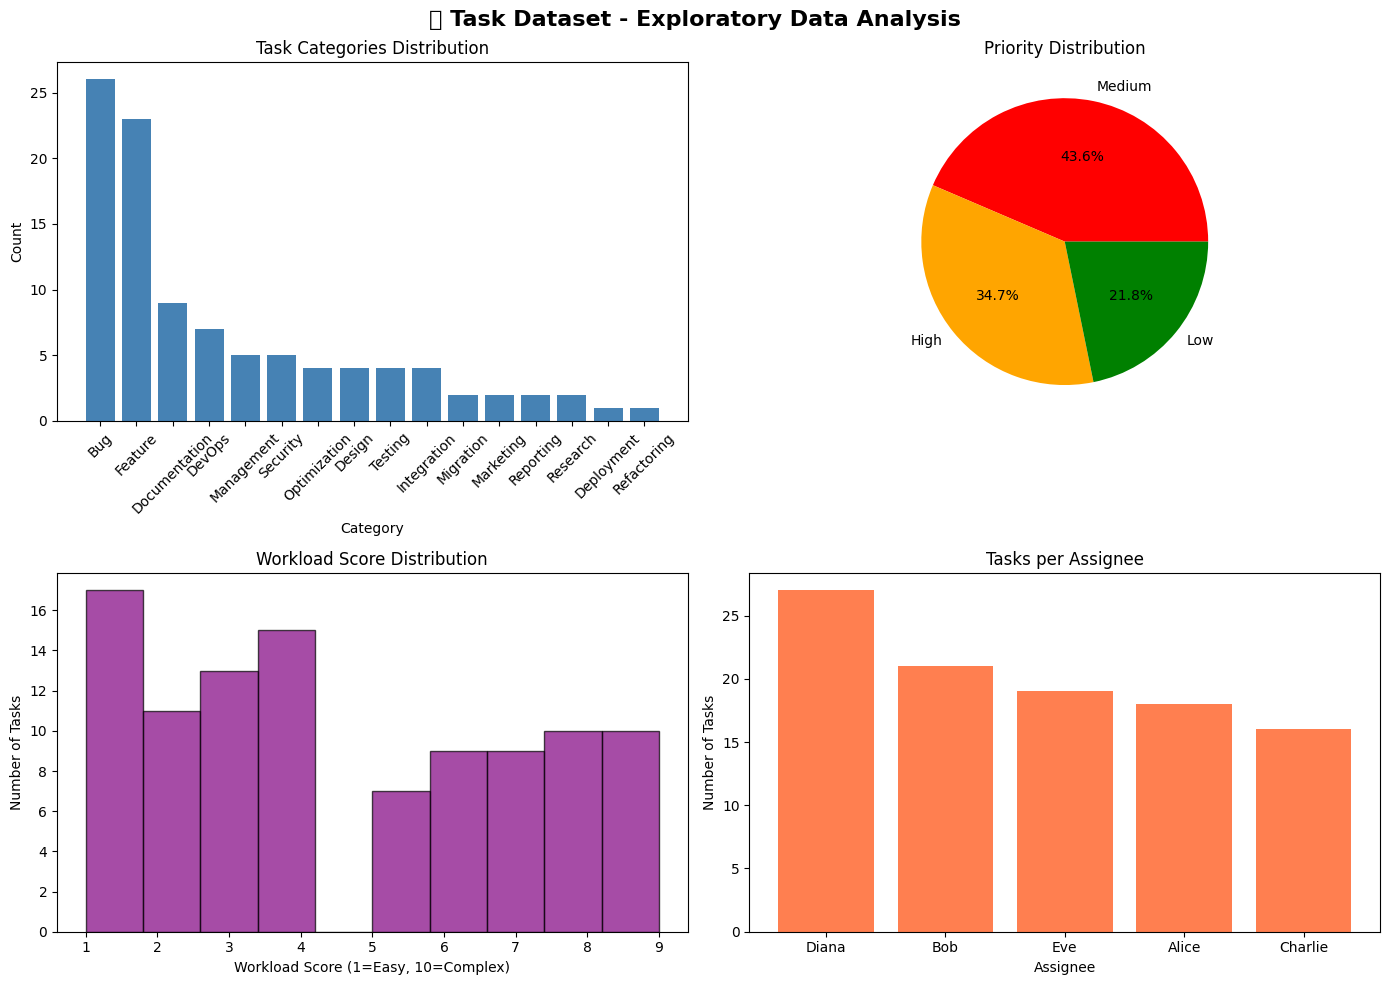

✅ EDA Visualizations complete!


In [5]:
# ============================================================
# EDA VISUALIZATIONS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('📊 Task Dataset - Exploratory Data Analysis', fontsize=16, fontweight='bold')

# Plot 1: Category Distribution
category_counts = df['category'].value_counts()
axes[0,0].bar(category_counts.index, category_counts.values, color='steelblue')
axes[0,0].set_title('Task Categories Distribution')
axes[0,0].set_xlabel('Category')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=45)

# Plot 2: Priority Distribution
priority_counts = df['priority'].value_counts()
colors = ['red','orange','green']
axes[0,1].pie(priority_counts.values, labels=priority_counts.index,
              autopct='%1.1f%%', colors=colors)
axes[0,1].set_title('Priority Distribution')

# Plot 3: Workload Score Distribution
axes[1,0].hist(df['workload_score'], bins=10, color='purple', alpha=0.7, edgecolor='black')
axes[1,0].set_title('Workload Score Distribution')
axes[1,0].set_xlabel('Workload Score (1=Easy, 10=Complex)')
axes[1,0].set_ylabel('Number of Tasks')

# Plot 4: Assignee Workload
assignee_counts = df['assignee'].value_counts()
axes[1,1].bar(assignee_counts.index, assignee_counts.values, color='coral')
axes[1,1].set_title('Tasks per Assignee')
axes[1,1].set_xlabel('Assignee')
axes[1,1].set_ylabel('Number of Tasks')

plt.tight_layout()
plt.savefig('eda_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA Visualizations complete!")

In [9]:
# ============================================================
# NLP PREPROCESSING ON TASK DESCRIPTIONS
# ============================================================

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text):
    """
    Cleans and preprocesses a task description.
    Steps: lowercase → remove special chars → tokenize → remove stopwords → stem
    """
    # Step 1: Lowercase
    text = text.lower()

    # Step 2: Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Step 3: Tokenize (split into words)
    tokens = word_tokenize(text)

    # Step 4: Remove stopwords (common words like 'the', 'is', 'in')
    tokens = [word for word in tokens if word not in stop_words]

    # Step 5: Stemming (reduce words to root form e.g. 'running' → 'run')
    tokens = [stemmer.stem(word) for word in tokens]

    # Step 6: Join back into a string
    return ' '.join(tokens)

# Apply preprocessing to all descriptions
df['cleaned_description'] = df['description'].apply(preprocess_text)

print("✅ NLP Preprocessing Done!")
print("\n📝 BEFORE vs AFTER preprocessing:")
print("-"*70)
for i in range(3):
    print(f"\nOriginal : {df['description'].iloc[i]}")
    print(f"Cleaned  : {df['cleaned_description'].iloc[i]}")

✅ NLP Preprocessing Done!

📝 BEFORE vs AFTER preprocessing:
----------------------------------------------------------------------

Original : Fix critical login bug causing users to be locked out
Cleaned  : fix critic login bug caus user lock

Original : Design new homepage UI with modern layout
Cleaned  : design new homepag ui modern layout

Original : Write unit tests for payment module
Cleaned  : write unit test payment modul


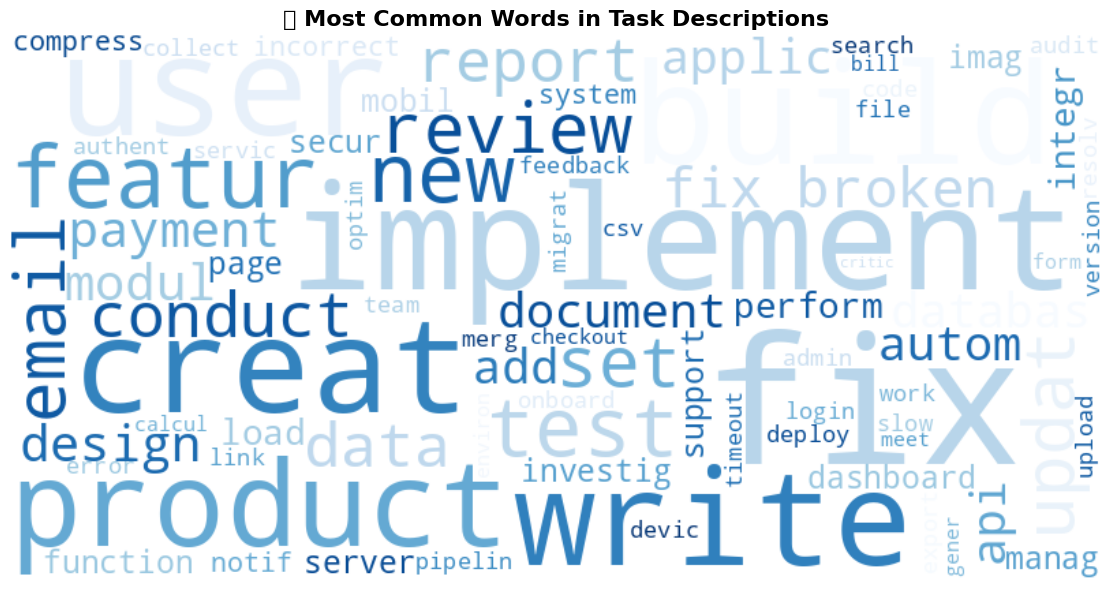

✅ WordCloud generated!


In [10]:
# ============================================================
# WORDCLOUD - Most Common Words in Task Descriptions
# ============================================================

from wordcloud import WordCloud

all_text = ' '.join(df['cleaned_description'].values)

wordcloud = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Blues',
    max_words=80
).generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('🔤 Most Common Words in Task Descriptions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ WordCloud generated!")

In [11]:
# ============================================================
# SAVE CLEANED DATASET FOR WEEK 2
# ============================================================

df.to_csv('task_dataset_cleaned.csv', index=False)
print("✅ Dataset saved as 'task_dataset_cleaned.csv'")
print(f"Final shape: {df.shape}")
print("\nColumns available for Week 2:")
print(df.columns.tolist())

✅ Dataset saved as 'task_dataset_cleaned.csv'
Final shape: (101, 8)

Columns available for Week 2:
['task_id', 'description', 'category', 'priority', 'assignee', 'deadline_days', 'workload_score', 'cleaned_description']


## Week 2: Feature Extraction, Task Classification & Evaluation

In [12]:
# ============================================================
# LOAD THE CLEANED DATASET FROM WEEK 1
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('task_dataset_cleaned.csv')

print("✅ Dataset loaded successfully!")
print(f"Shape: {df.shape}")
df.head()

✅ Dataset loaded successfully!
Shape: (101, 8)


,task_id,description,category,priority,assignee,deadline_days,workload_score,cleaned_description
0,1,Fix critical login bug causing users to be loc...,Bug,High,Diana,7,1,fix critic login bug caus user lock
1,2,Design new homepage UI with modern layout,Design,Medium,Eve,9,4,design new homepag ui modern layout
2,3,Write unit tests for payment module,Testing,Low,Charlie,8,7,write unit test payment modul
3,4,Deploy application to AWS production server,Deployment,High,Eve,12,2,deploy applic aw product server
4,5,Update API documentation for v2 endpoints,Documentation,Low,Eve,2,3,updat api document v endpoint


In [13]:
# ============================================================
# ENCODE CATEGORY LABELS INTO NUMBERS
# (ML models need numbers, not text labels)
# ============================================================

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['category_encoded'] = le.fit_transform(df['category'])

print("✅ Label Encoding Done!")
print("\nCategory → Number Mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} → {i}")

✅ Label Encoding Done!

Category → Number Mapping:
  Bug → 0
  Deployment → 1
  Design → 2
  DevOps → 3
  Documentation → 4
  Feature → 5
  Integration → 6
  Management → 7
  Marketing → 8
  Migration → 9
  Optimization → 10
  Refactoring → 11
  Reporting → 12
  Research → 13
  Security → 14
  Testing → 15


In [14]:
# ============================================================
# TF-IDF FEATURE EXTRACTION
# Converts text descriptions into numbers that ML can understand
# Think of it like: each word gets a score based on how
# important it is in that task description
# ============================================================

tfidf = TfidfVectorizer(max_features=500)  # Use top 500 words

X = tfidf.fit_transform(df['cleaned_description']).toarray()
y = df['category_encoded']

print("✅ TF-IDF Feature Extraction Done!")
print(f"Feature Matrix Shape: {X.shape}")
print(f"→ {X.shape[0]} tasks, {X.shape[1]} features (words)")

✅ TF-IDF Feature Extraction Done!
Feature Matrix Shape: (101, 254)
→ 101 tasks, 254 features (words)


In [16]:
# ============================================================
# SPLIT DATA INTO TRAINING AND TESTING SETS
# 80% for training, 20% for testing
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
    # removed stratify=y because some categories have too few samples
)

print("✅ Data Split Done!")
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

✅ Data Split Done!
Training samples : 80
Testing samples  : 21


In [17]:
# ============================================================
# MODEL 1: NAIVE BAYES CLASSIFIER
# A simple but powerful text classification algorithm
# Works great with TF-IDF features
# ============================================================

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Predictions
nb_predictions = nb_model.predict(X_test)

# Evaluation
nb_accuracy  = accuracy_score(y_test, nb_predictions)
nb_precision = precision_score(y_test, nb_predictions, average='weighted', zero_division=0)
nb_recall    = recall_score(y_test, nb_predictions, average='weighted', zero_division=0)
nb_f1        = f1_score(y_test, nb_predictions, average='weighted', zero_division=0)

print("✅ Naive Bayes Model Trained!")
print(f"\n📊 Naive Bayes Results:")
print(f"  Accuracy  : {nb_accuracy:.2f}")
print(f"  Precision : {nb_precision:.2f}")
print(f"  Recall    : {nb_recall:.2f}")
print(f"  F1 Score  : {nb_f1:.2f}")

✅ Naive Bayes Model Trained!

📊 Naive Bayes Results:
  Accuracy  : 0.24
  Precision : 0.12
  Recall    : 0.24
  F1 Score  : 0.16


In [18]:
# ============================================================
# MODEL 2: SVM (Support Vector Machine) CLASSIFIER
# More powerful than Naive Bayes for text classification
# Finds the best boundary between different categories
# ============================================================

svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

# Predictions
svm_predictions = svm_model.predict(X_test)

# Evaluation
svm_accuracy  = accuracy_score(y_test, svm_predictions)
svm_precision = precision_score(y_test, svm_predictions, average='weighted', zero_division=0)
svm_recall    = recall_score(y_test, svm_predictions, average='weighted', zero_division=0)
svm_f1        = f1_score(y_test, svm_predictions, average='weighted', zero_division=0)

print("✅ SVM Model Trained!")
print(f"\n📊 SVM Results:")
print(f"  Accuracy  : {svm_accuracy:.2f}")
print(f"  Precision : {svm_precision:.2f}")
print(f"  Recall    : {svm_recall:.2f}")
print(f"  F1 Score  : {svm_f1:.2f}")

✅ SVM Model Trained!

📊 SVM Results:
  Accuracy  : 0.43
  Precision : 0.34
  Recall    : 0.43
  F1 Score  : 0.33


📊 MODEL COMPARISON:
      Model  Accuracy  Precision   Recall  F1 Score
Naive Bayes  0.238095   0.120346 0.238095  0.157937
        SVM  0.428571   0.336219 0.428571  0.327408


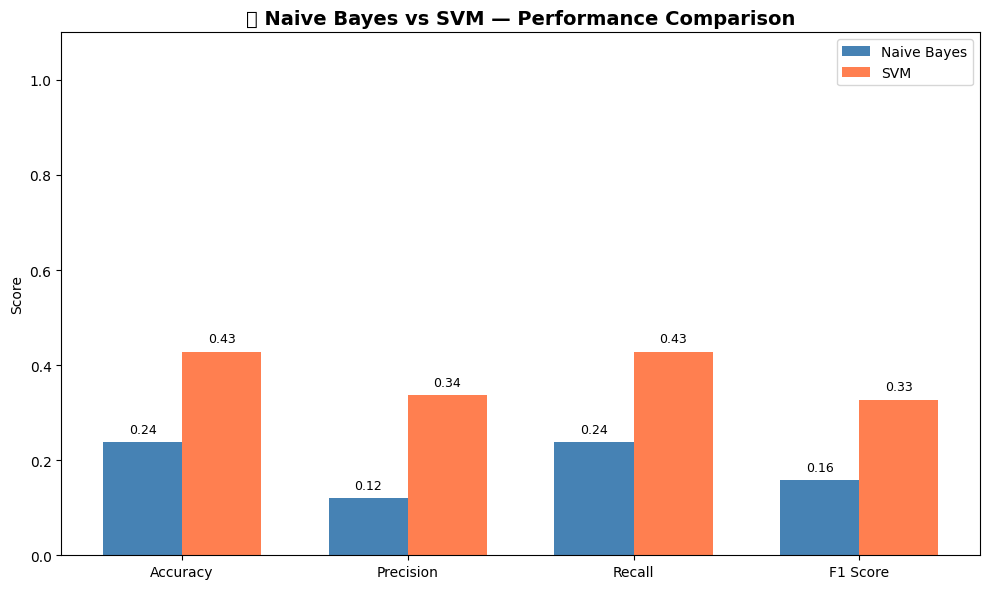

✅ Comparison chart saved!


In [19]:
# ============================================================
# COMPARE NAIVE BAYES vs SVM
# ============================================================

results_df = pd.DataFrame({
    'Model'    : ['Naive Bayes', 'SVM'],
    'Accuracy' : [nb_accuracy, svm_accuracy],
    'Precision': [nb_precision, svm_precision],
    'Recall'   : [nb_recall, svm_recall],
    'F1 Score' : [nb_f1, svm_f1]
})

print("📊 MODEL COMPARISON:")
print("="*55)
print(results_df.to_string(index=False))

# Bar chart comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
nb_scores  = [nb_accuracy, nb_precision, nb_recall, nb_f1]
svm_scores = [svm_accuracy, svm_precision, svm_recall, svm_f1]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, nb_scores,  width, label='Naive Bayes', color='steelblue')
bars2 = ax.bar(x + width/2, svm_scores, width, label='SVM',         color='coral')

ax.set_title('📊 Naive Bayes vs SVM — Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.legend()

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparison chart saved!")

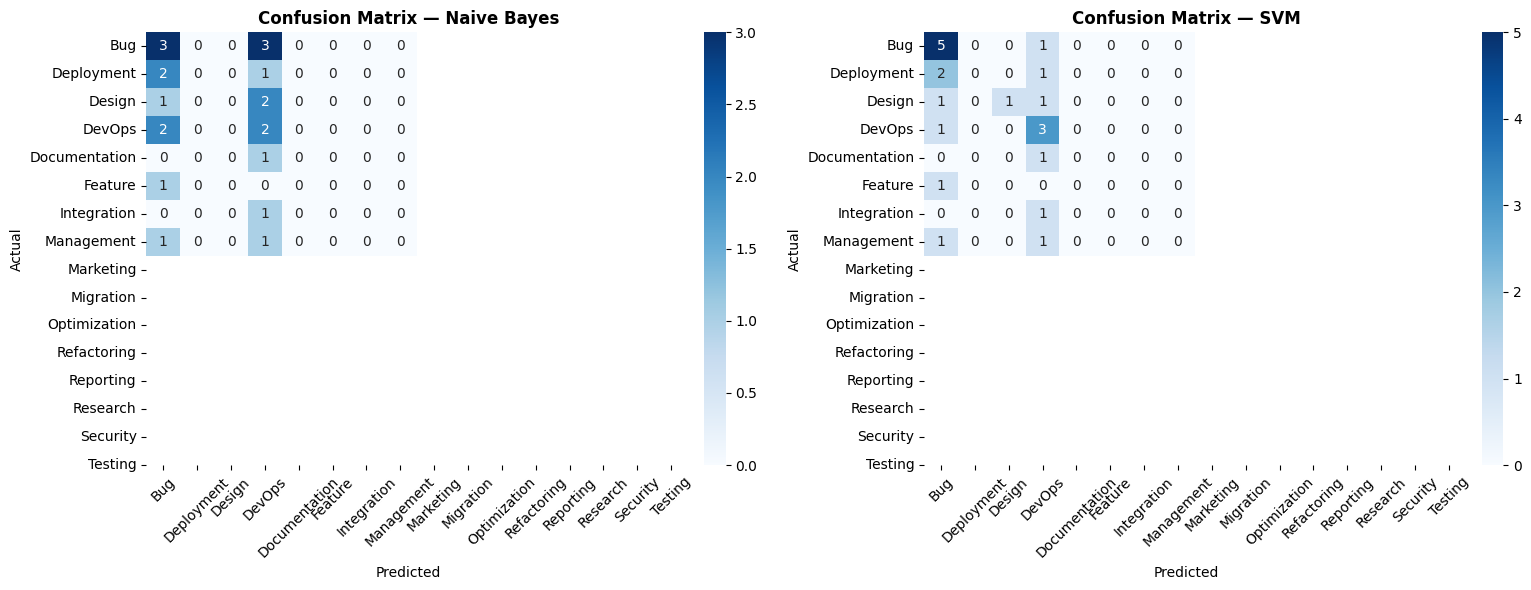

✅ Confusion matrices saved!


In [20]:
# ============================================================
# CONFUSION MATRIX FOR BEST MODEL (SVM)
# Shows which categories are being confused with each other
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, predictions, title in zip(
    axes,
    [nb_predictions, svm_predictions],
    ['Naive Bayes', 'SVM']
):
    cm = confusion_matrix(y_test, predictions)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=le.classes_,
        yticklabels=le.classes_,
        ax=ax
    )
    ax.set_title(f'Confusion Matrix — {title}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrices saved!")

In [22]:
# ============================================================
# DETAILED CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report
import numpy as np

# Get only the classes that actually appear in y_test
classes_in_test = np.unique(y_test)
class_names = le.inverse_transform(classes_in_test)

print("📋 NAIVE BAYES — Detailed Report:")
print("="*55)
print(classification_report(
    y_test, nb_predictions,
    labels=classes_in_test,
    target_names=class_names,
    zero_division=0
))

print("\n📋 SVM — Detailed Report:")
print("="*55)
print(classification_report(
    y_test, svm_predictions,
    labels=classes_in_test,
    target_names=class_names,
    zero_division=0
))

📋 NAIVE BAYES — Detailed Report:
               precision    recall  f1-score   support

          Bug       0.30      0.50      0.38         6
       DevOps       0.00      0.00      0.00         3
Documentation       0.00      0.00      0.00         3
      Feature       0.18      0.50      0.27         4
  Integration       0.00      0.00      0.00         1
   Management       0.00      0.00      0.00         1
    Marketing       0.00      0.00      0.00         1
     Research       0.00      0.00      0.00         2

     accuracy                           0.24        21
    macro avg       0.06      0.12      0.08        21
 weighted avg       0.12      0.24      0.16        21


📋 SVM — Detailed Report:
               precision    recall  f1-score   support

          Bug       0.45      0.83      0.59         6
       DevOps       0.00      0.00      0.00         3
Documentation       1.00      0.33      0.50         3
      Feature       0.33      0.75      0.46         4
  

In [23]:
# ============================================================
# SAVE MODELS & OBJECTS FOR USE IN WEEK 3
# ============================================================

import pickle

# Save SVM model (best performer)
with open('svm_model.pkl', 'wb') as f:
    pickle.dump(svm_model, f)

# Save Naive Bayes model
with open('nb_model.pkl', 'wb') as f:
    pickle.dump(nb_model, f)

# Save TF-IDF vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# Save Label Encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# Save dataframe for week 3
df.to_csv('task_dataset_week2.csv', index=False)

print("✅ All models and objects saved!")
print("  → svm_model.pkl")
print("  → nb_model.pkl")
print("  → tfidf_vectorizer.pkl")
print("  → label_encoder.pkl")
print("  → task_dataset_week2.csv")

✅ All models and objects saved!
  → svm_model.pkl
  → nb_model.pkl
  → tfidf_vectorizer.pkl
  → label_encoder.pkl
  → task_dataset_week2.csv


## Week 3: Priority Prediction, Workload Balancing & Hyperparameter Tuning


In [24]:
# ============================================================
# LOAD DATASET & IMPORT LIBRARIES FOR WEEK 3
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from xgboost import XGBClassifier

# Load dataset from week 2
df = pd.read_csv('task_dataset_week2.csv')

print("✅ Dataset loaded!")
print(f"Shape: {df.shape}")
df.head()

✅ Dataset loaded!
Shape: (101, 9)


,task_id,description,category,priority,assignee,deadline_days,workload_score,cleaned_description,category_encoded
0,1,Fix critical login bug causing users to be loc...,Bug,High,Diana,7,1,fix critic login bug caus user lock,0
1,2,Design new homepage UI with modern layout,Design,Medium,Eve,9,4,design new homepag ui modern layout,2
2,3,Write unit tests for payment module,Testing,Low,Charlie,8,7,write unit test payment modul,15
3,4,Deploy application to AWS production server,Deployment,High,Eve,12,2,deploy applic aw product server,1
4,5,Update API documentation for v2 endpoints,Documentation,Low,Eve,2,3,updat api document v endpoint,4


In [25]:
# ============================================================
# PREPARE FEATURES FOR PRIORITY PREDICTION
# We will predict PRIORITY (High/Medium/Low)
# using: category, deadline_days, workload_score
# ============================================================

# Encode priority (target)
priority_encoder = LabelEncoder()
df['priority_encoded'] = priority_encoder.fit_transform(df['priority'])

print("Priority → Number Mapping:")
for i, cls in enumerate(priority_encoder.classes_):
    print(f"  {cls} → {i}")

# Encode category (feature)
category_encoder = LabelEncoder()
df['category_encoded'] = category_encoder.fit_transform(df['category'])

# Features and Target
X = df[['category_encoded', 'deadline_days', 'workload_score']]
y = df['priority_encoded']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n✅ Features ready!")
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")
print(f"\nFeatures used: {list(X.columns)}")

Priority → Number Mapping:
  High → 0
  Low → 1
  Medium → 2

✅ Features ready!
Training samples : 80
Testing samples  : 21

Features used: ['category_encoded', 'deadline_days', 'workload_score']


In [26]:
# ============================================================
# MODEL 1: RANDOM FOREST FOR PRIORITY PREDICTION
# Think of it like asking 100 decision trees and
# taking the majority vote — very powerful!
# ============================================================

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_accuracy  = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions, average='weighted', zero_division=0)
rf_recall    = recall_score(y_test, rf_predictions, average='weighted', zero_division=0)
rf_f1        = f1_score(y_test, rf_predictions, average='weighted', zero_division=0)

print("✅ Random Forest Trained!")
print(f"\n📊 Random Forest Results:")
print(f"  Accuracy  : {rf_accuracy:.2f}")
print(f"  Precision : {rf_precision:.2f}")
print(f"  Recall    : {rf_recall:.2f}")
print(f"  F1 Score  : {rf_f1:.2f}")

✅ Random Forest Trained!

📊 Random Forest Results:
  Accuracy  : 0.33
  Precision : 0.31
  Recall    : 0.33
  F1 Score  : 0.32


In [27]:
# ============================================================
# MODEL 2: XGBOOST FOR PRIORITY PREDICTION
# A more advanced model that learns from its own mistakes
# (boosting = each tree fixes errors of the previous one)
# ============================================================

xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss',
    verbosity=0
)
xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)

xgb_accuracy  = accuracy_score(y_test, xgb_predictions)
xgb_precision = precision_score(y_test, xgb_predictions, average='weighted', zero_division=0)
xgb_recall    = recall_score(y_test, xgb_predictions, average='weighted', zero_division=0)
xgb_f1        = f1_score(y_test, xgb_predictions, average='weighted', zero_division=0)

print("✅ XGBoost Trained!")
print(f"\n📊 XGBoost Results:")
print(f"  Accuracy  : {xgb_accuracy:.2f}")
print(f"  Precision : {xgb_precision:.2f}")
print(f"  Recall    : {xgb_recall:.2f}")
print(f"  F1 Score  : {xgb_f1:.2f}")

✅ XGBoost Trained!

📊 XGBoost Results:
  Accuracy  : 0.29
  Precision : 0.27
  Recall    : 0.29
  F1 Score  : 0.28


📊 MODEL COMPARISON — Priority Prediction:
        Model  Accuracy  Precision   Recall  F1 Score
Random Forest  0.333333   0.306122 0.333333  0.317460
      XGBoost  0.285714   0.272109 0.285714  0.277778


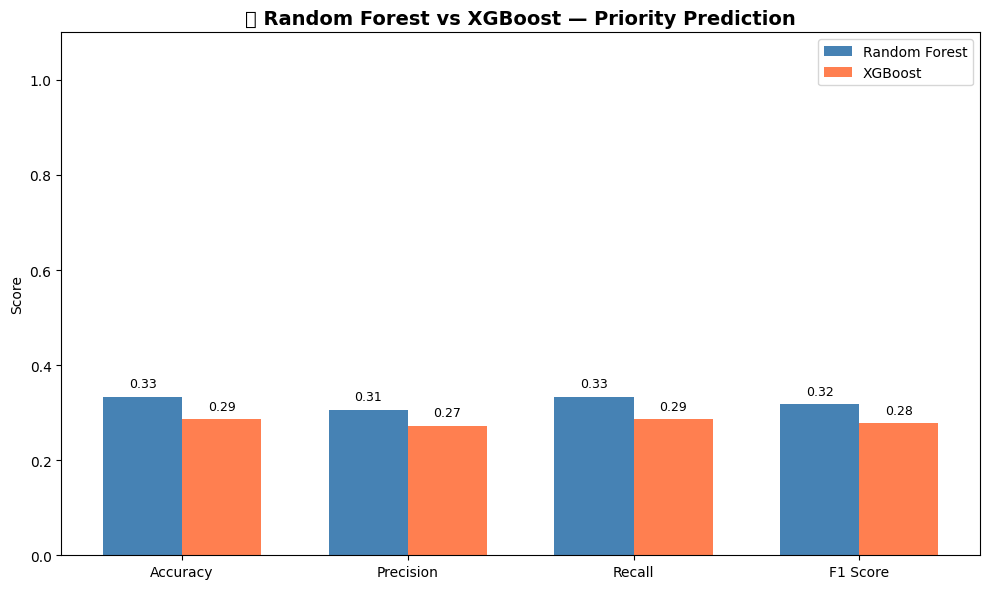

✅ Comparison chart saved!


In [28]:
# ============================================================
# COMPARE RANDOM FOREST vs XGBOOST
# ============================================================

results_df = pd.DataFrame({
    'Model'    : ['Random Forest', 'XGBoost'],
    'Accuracy' : [rf_accuracy,  xgb_accuracy],
    'Precision': [rf_precision, xgb_precision],
    'Recall'   : [rf_recall,    xgb_recall],
    'F1 Score' : [rf_f1,        xgb_f1]
})

print("📊 MODEL COMPARISON — Priority Prediction:")
print("="*55)
print(results_df.to_string(index=False))

# Bar chart
metrics   = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
rf_scores  = [rf_accuracy,  rf_precision,  rf_recall,  rf_f1]
xgb_scores = [xgb_accuracy, xgb_precision, xgb_recall, xgb_f1]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, rf_scores,  width, label='Random Forest', color='steelblue')
bars2 = ax.bar(x + width/2, xgb_scores, width, label='XGBoost',       color='coral')

ax.set_title('📊 Random Forest vs XGBoost — Priority Prediction', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('priority_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparison chart saved!")

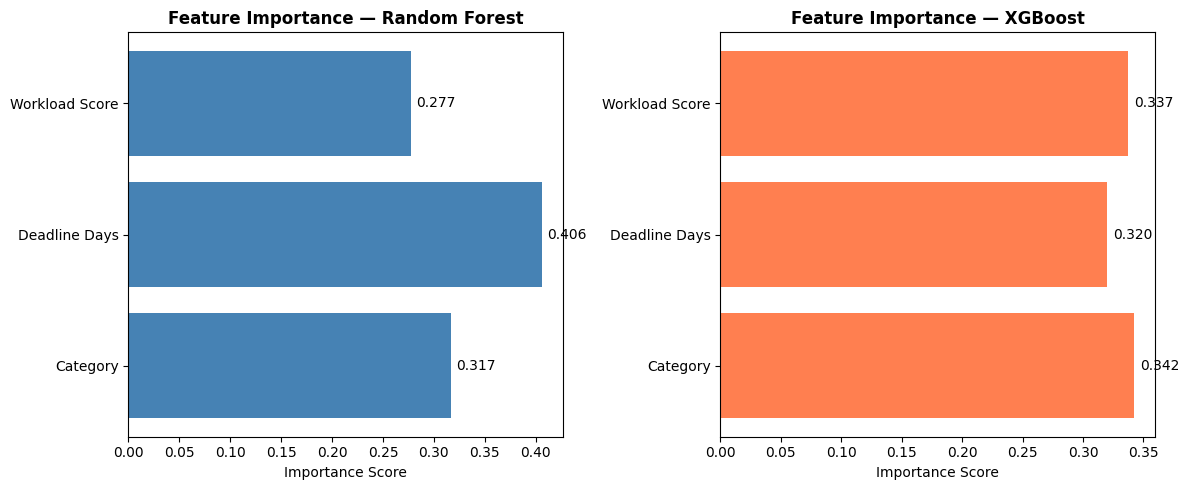

✅ Feature importance chart saved!


In [29]:
# ============================================================
# FEATURE IMPORTANCE — What matters most for priority?
# ============================================================

feature_names       = ['Category', 'Deadline Days', 'Workload Score']
rf_importances      = rf_model.feature_importances_
xgb_importances     = xgb_model.feature_importances_

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, importances, title, color in zip(
    axes,
    [rf_importances, xgb_importances],
    ['Random Forest', 'XGBoost'],
    ['steelblue', 'coral']
):
    ax.barh(feature_names, importances, color=color)
    ax.set_title(f'Feature Importance — {title}', fontweight='bold')
    ax.set_xlabel('Importance Score')
    for i, v in enumerate(importances):
        ax.text(v + 0.005, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance chart saved!")

In [30]:
# ============================================================
# WORKLOAD BALANCING
# Distributes tasks fairly across team members
# based on their current workload score
# ============================================================

def assign_task(task_row, team_workload):
    """
    Assigns a task to the team member with the lowest workload.
    team_workload = dictionary of {name: current_workload_score}
    """
    # Pick the person with lowest workload
    assignee = min(team_workload, key=team_workload.get)

    # Update their workload
    team_workload[assignee] += task_row['workload_score']

    return assignee

# Start with equal workload for everyone
team_workload = {
    'Alice'  : 0,
    'Bob'    : 0,
    'Charlie': 0,
    'Diana'  : 0,
    'Eve'    : 0
}

# Sort tasks by priority first (High → Medium → Low)
priority_order = {'High': 0, 'Medium': 1, 'Low': 2}
df_sorted = df.copy()
df_sorted['priority_order'] = df_sorted['priority'].map(priority_order)
df_sorted = df_sorted.sort_values('priority_order')

# Assign tasks
df_sorted['balanced_assignee'] = df_sorted.apply(
    lambda row: assign_task(row, team_workload), axis=1
)

print("✅ Workload Balancing Done!")
print("\n📊 Final Workload Distribution:")
for person, load in team_workload.items():
    bar = '█' * (load // 5)
    print(f"  {person:<10}: {load:>3} pts  {bar}")

print("\n📋 Sample Task Assignments:")
print(df_sorted[['task_id','description','priority','balanced_assignee','workload_score']].head(10).to_string(index=False))

✅ Workload Balancing Done!

📊 Final Workload Distribution:
  Alice     :  95 pts  ███████████████████
  Bob       :  90 pts  ██████████████████
  Charlie   :  90 pts  ██████████████████
  Diana     :  92 pts  ██████████████████
  Eve       :  93 pts  ██████████████████

📋 Sample Task Assignments:
 task_id                                           description priority balanced_assignee  workload_score
       1 Fix critical login bug causing users to be locked out     High             Alice               1
       4           Deploy application to AWS production server     High               Bob               2
       8          Optimize slow database queries on user table     High           Charlie               1
       6         Investigate memory leak in background service     High             Diana               1
      16                Resolve payment gateway timeout errors     High               Eve               5
      15                 Add search functionality to dashboard    

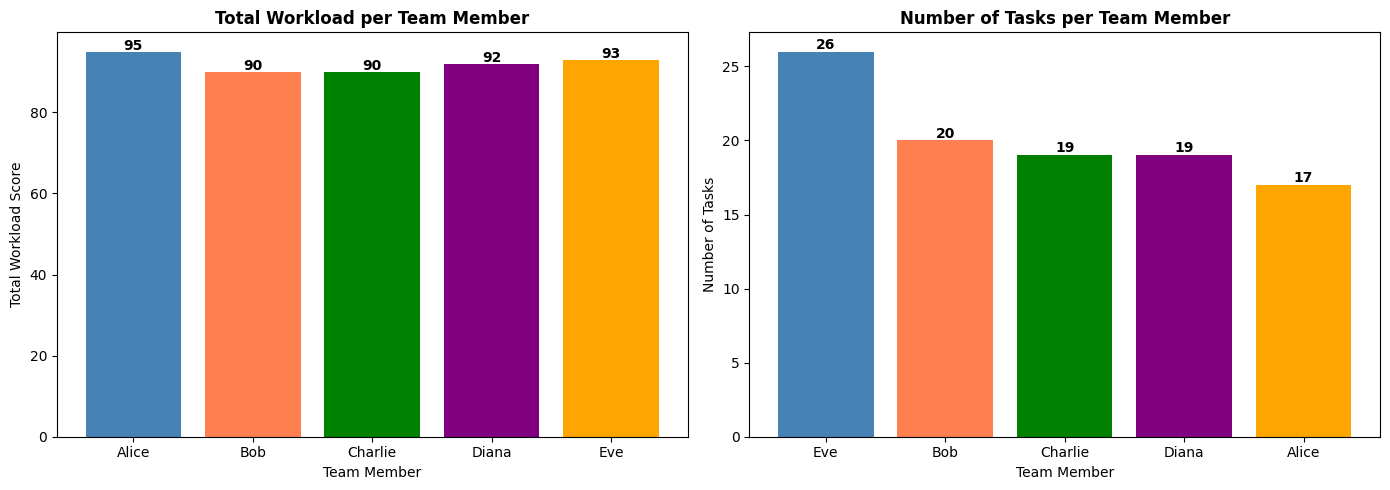

✅ Workload distribution chart saved!


In [31]:
# ============================================================
# VISUALIZE WORKLOAD DISTRIBUTION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Total workload per person
people = list(team_workload.keys())
loads  = list(team_workload.values())

axes[0].bar(people, loads, color=['steelblue','coral','green','purple','orange'])
axes[0].set_title('Total Workload per Team Member', fontweight='bold')
axes[0].set_xlabel('Team Member')
axes[0].set_ylabel('Total Workload Score')
for i, v in enumerate(loads):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Plot 2: Number of tasks per person
task_counts = df_sorted['balanced_assignee'].value_counts()
axes[1].bar(task_counts.index, task_counts.values,
            color=['steelblue','coral','green','purple','orange'])
axes[1].set_title('Number of Tasks per Team Member', fontweight='bold')
axes[1].set_xlabel('Team Member')
axes[1].set_ylabel('Number of Tasks')
for i, v in enumerate(task_counts.values):
    axes[1].text(i, v + 0.2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('workload_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Workload distribution chart saved!")

In [32]:
# ============================================================
# HYPERPARAMETER TUNING WITH GridSearchCV
# Tries different settings to find the BEST model
# Like testing different ingredients to find the best recipe!
# ============================================================

print("⏳ Running GridSearchCV... (this may take 1-2 minutes)")

param_grid = {
    'n_estimators'     : [50, 100, 200],
    'max_depth'        : [3, 5, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\n✅ GridSearchCV Done!")
print(f"Best Parameters : {grid_search.best_params_}")
print(f"Best CV Score   : {grid_search.best_score_:.2f}")

# Evaluate best model on test set
best_model      = grid_search.best_estimator_
best_predictions = best_model.predict(X_test)
best_accuracy   = accuracy_score(y_test, best_predictions)

print(f"Test Accuracy (Best Model): {best_accuracy:.2f}")

⏳ Running GridSearchCV... (this may take 1-2 minutes)
Fitting 3 folds for each of 18 candidates, totalling 54 fits

✅ GridSearchCV Done!
Best Parameters : {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score   : 0.41
Test Accuracy (Best Model): 0.38


📊 Cross Validation Results (5-Fold):
  Scores : [np.float64(0.29), np.float64(0.3), np.float64(0.5), np.float64(0.45), np.float64(0.45)]
  Mean   : 0.40
  Std Dev: 0.09


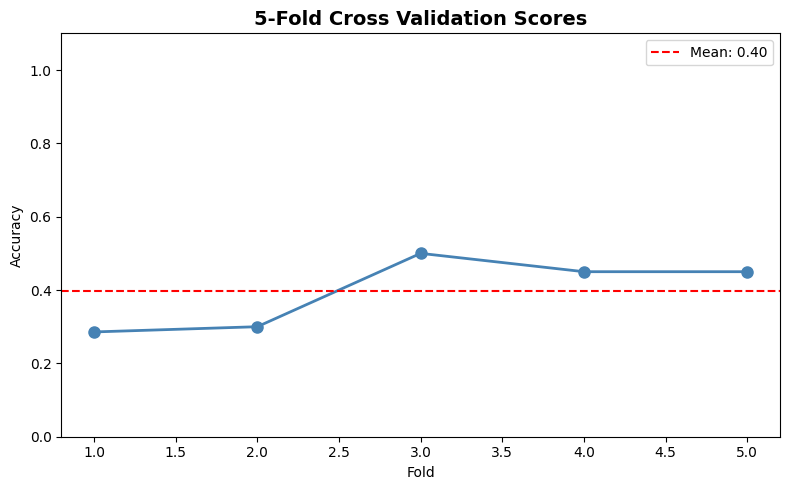


✅ All models saved for Week 4!
  → best_priority_model.pkl
  → priority_encoder.pkl
  → category_encoder.pkl
  → task_dataset_week3.csv


In [33]:
# ============================================================
# CROSS VALIDATION — More reliable accuracy estimate
# ============================================================

cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='accuracy')

print("📊 Cross Validation Results (5-Fold):")
print(f"  Scores : {[round(s, 2) for s in cv_scores]}")
print(f"  Mean   : {cv_scores.mean():.2f}")
print(f"  Std Dev: {cv_scores.std():.2f}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, 6), cv_scores, marker='o', color='steelblue', linewidth=2, markersize=8)
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f'Mean: {cv_scores.mean():.2f}')
plt.title('5-Fold Cross Validation Scores', fontsize=14, fontweight='bold')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.savefig('cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

# Save everything for Week 4
with open('best_priority_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('priority_encoder.pkl', 'wb') as f:
    pickle.dump(priority_encoder, f)

with open('category_encoder.pkl', 'wb') as f:
    pickle.dump(category_encoder, f)

df_sorted.to_csv('task_dataset_week3.csv', index=False)

print("\n✅ All models saved for Week 4!")
print("  → best_priority_model.pkl")
print("  → priority_encoder.pkl")
print("  → category_encoder.pkl")
print("  → task_dataset_week3.csv")

## Week 4: Final Models, Dashboard & Performance Summary

In [34]:
# ============================================================
# LOAD ALL SAVED MODELS & DATASETS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv('task_dataset_week3.csv')

# Load all models
with open('svm_model.pkl', 'rb') as f:
    svm_model = pickle.load(f)

with open('nb_model.pkl', 'rb') as f:
    nb_model = pickle.load(f)

with open('tfidf_vectorizer.pkl', 'rb') as f:
    tfidf = pickle.load(f)

with open('label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

with open('best_priority_model.pkl', 'rb') as f:
    best_priority_model = pickle.load(f)

with open('priority_encoder.pkl', 'rb') as f:
    priority_encoder = pickle.load(f)

with open('category_encoder.pkl', 'rb') as f:
    category_encoder = pickle.load(f)

print("✅ All models and data loaded successfully!")
print(f"Dataset shape: {df.shape}")
df.head()

✅ All models and data loaded successfully!
Dataset shape: (101, 12)


,task_id,description,category,priority,assignee,deadline_days,workload_score,cleaned_description,category_encoded,priority_encoded,priority_order,balanced_assignee
0,1,Fix critical login bug causing users to be loc...,Bug,High,Diana,7,1,fix critic login bug caus user lock,0,0,0,Alice
1,4,Deploy application to AWS production server,Deployment,High,Eve,12,2,deploy applic aw product server,1,0,0,Bob
2,8,Optimize slow database queries on user table,Optimization,High,Charlie,23,1,optim slow databas queri user tabl,10,0,0,Charlie
3,6,Investigate memory leak in background service,Bug,High,Bob,1,1,investig memori leak background servic,0,0,0,Diana
4,16,Resolve payment gateway timeout errors,Bug,High,Bob,27,5,resolv payment gateway timeout error,0,0,0,Eve


In [35]:
# ============================================================
# REBUILD TEST SETS FOR FINAL EVALUATION
# ============================================================

# --- Task Classification (Category) ---
df['category_encoded'] = le.transform(df['category'])
X_tfidf = tfidf.transform(df['cleaned_description']).toarray()
y_cat   = df['category_encoded']

_, X_test_cat, _, y_test_cat = train_test_split(
    X_tfidf, y_cat, test_size=0.2, random_state=42
)

svm_preds = svm_model.predict(X_test_cat)
nb_preds  = nb_model.predict(X_test_cat)

# --- Priority Prediction ---
X_pri = df[['category_encoded', 'deadline_days', 'workload_score']]
y_pri = priority_encoder.transform(df['priority'])

_, X_test_pri, _, y_test_pri = train_test_split(
    X_pri, y_pri, test_size=0.2, random_state=42
)

pri_preds = best_priority_model.predict(X_test_pri)

print("✅ Test sets rebuilt!")
print(f"Classification test size : {len(y_test_cat)}")
print(f"Priority test size       : {len(y_test_pri)}")

✅ Test sets rebuilt!
Classification test size : 21
Priority test size       : 21


In [36]:
# ============================================================
# FINAL METRICS SUMMARY — ALL MODELS
# ============================================================

def get_metrics(y_true, y_pred):
    return {
        'Accuracy' : round(accuracy_score(y_true, y_pred), 3),
        'Precision': round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 3),
        'Recall'   : round(recall_score(y_true, y_pred, average='weighted', zero_division=0), 3),
        'F1 Score' : round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 3)
    }

metrics_svm = get_metrics(y_test_cat, svm_preds)
metrics_nb  = get_metrics(y_test_cat, nb_preds)
metrics_pri = get_metrics(y_test_pri, pri_preds)

summary_df = pd.DataFrame({
    'Model'    : ['SVM (Category)', 'Naive Bayes (Category)', 'Random Forest (Priority)'],
    'Accuracy' : [metrics_svm['Accuracy'],  metrics_nb['Accuracy'],  metrics_pri['Accuracy']],
    'Precision': [metrics_svm['Precision'], metrics_nb['Precision'], metrics_pri['Precision']],
    'Recall'   : [metrics_svm['Recall'],    metrics_nb['Recall'],    metrics_pri['Recall']],
    'F1 Score' : [metrics_svm['F1 Score'],  metrics_nb['F1 Score'],  metrics_pri['F1 Score']]
})

print("📊 FINAL MODEL PERFORMANCE SUMMARY")
print("="*65)
print(summary_df.to_string(index=False))

📊 FINAL MODEL PERFORMANCE SUMMARY
                   Model  Accuracy  Precision  Recall  F1 Score
          SVM (Category)     0.810      0.712   0.810     0.743
  Naive Bayes (Category)     0.524      0.332   0.524     0.404
Random Forest (Priority)     0.762      0.693   0.762     0.724


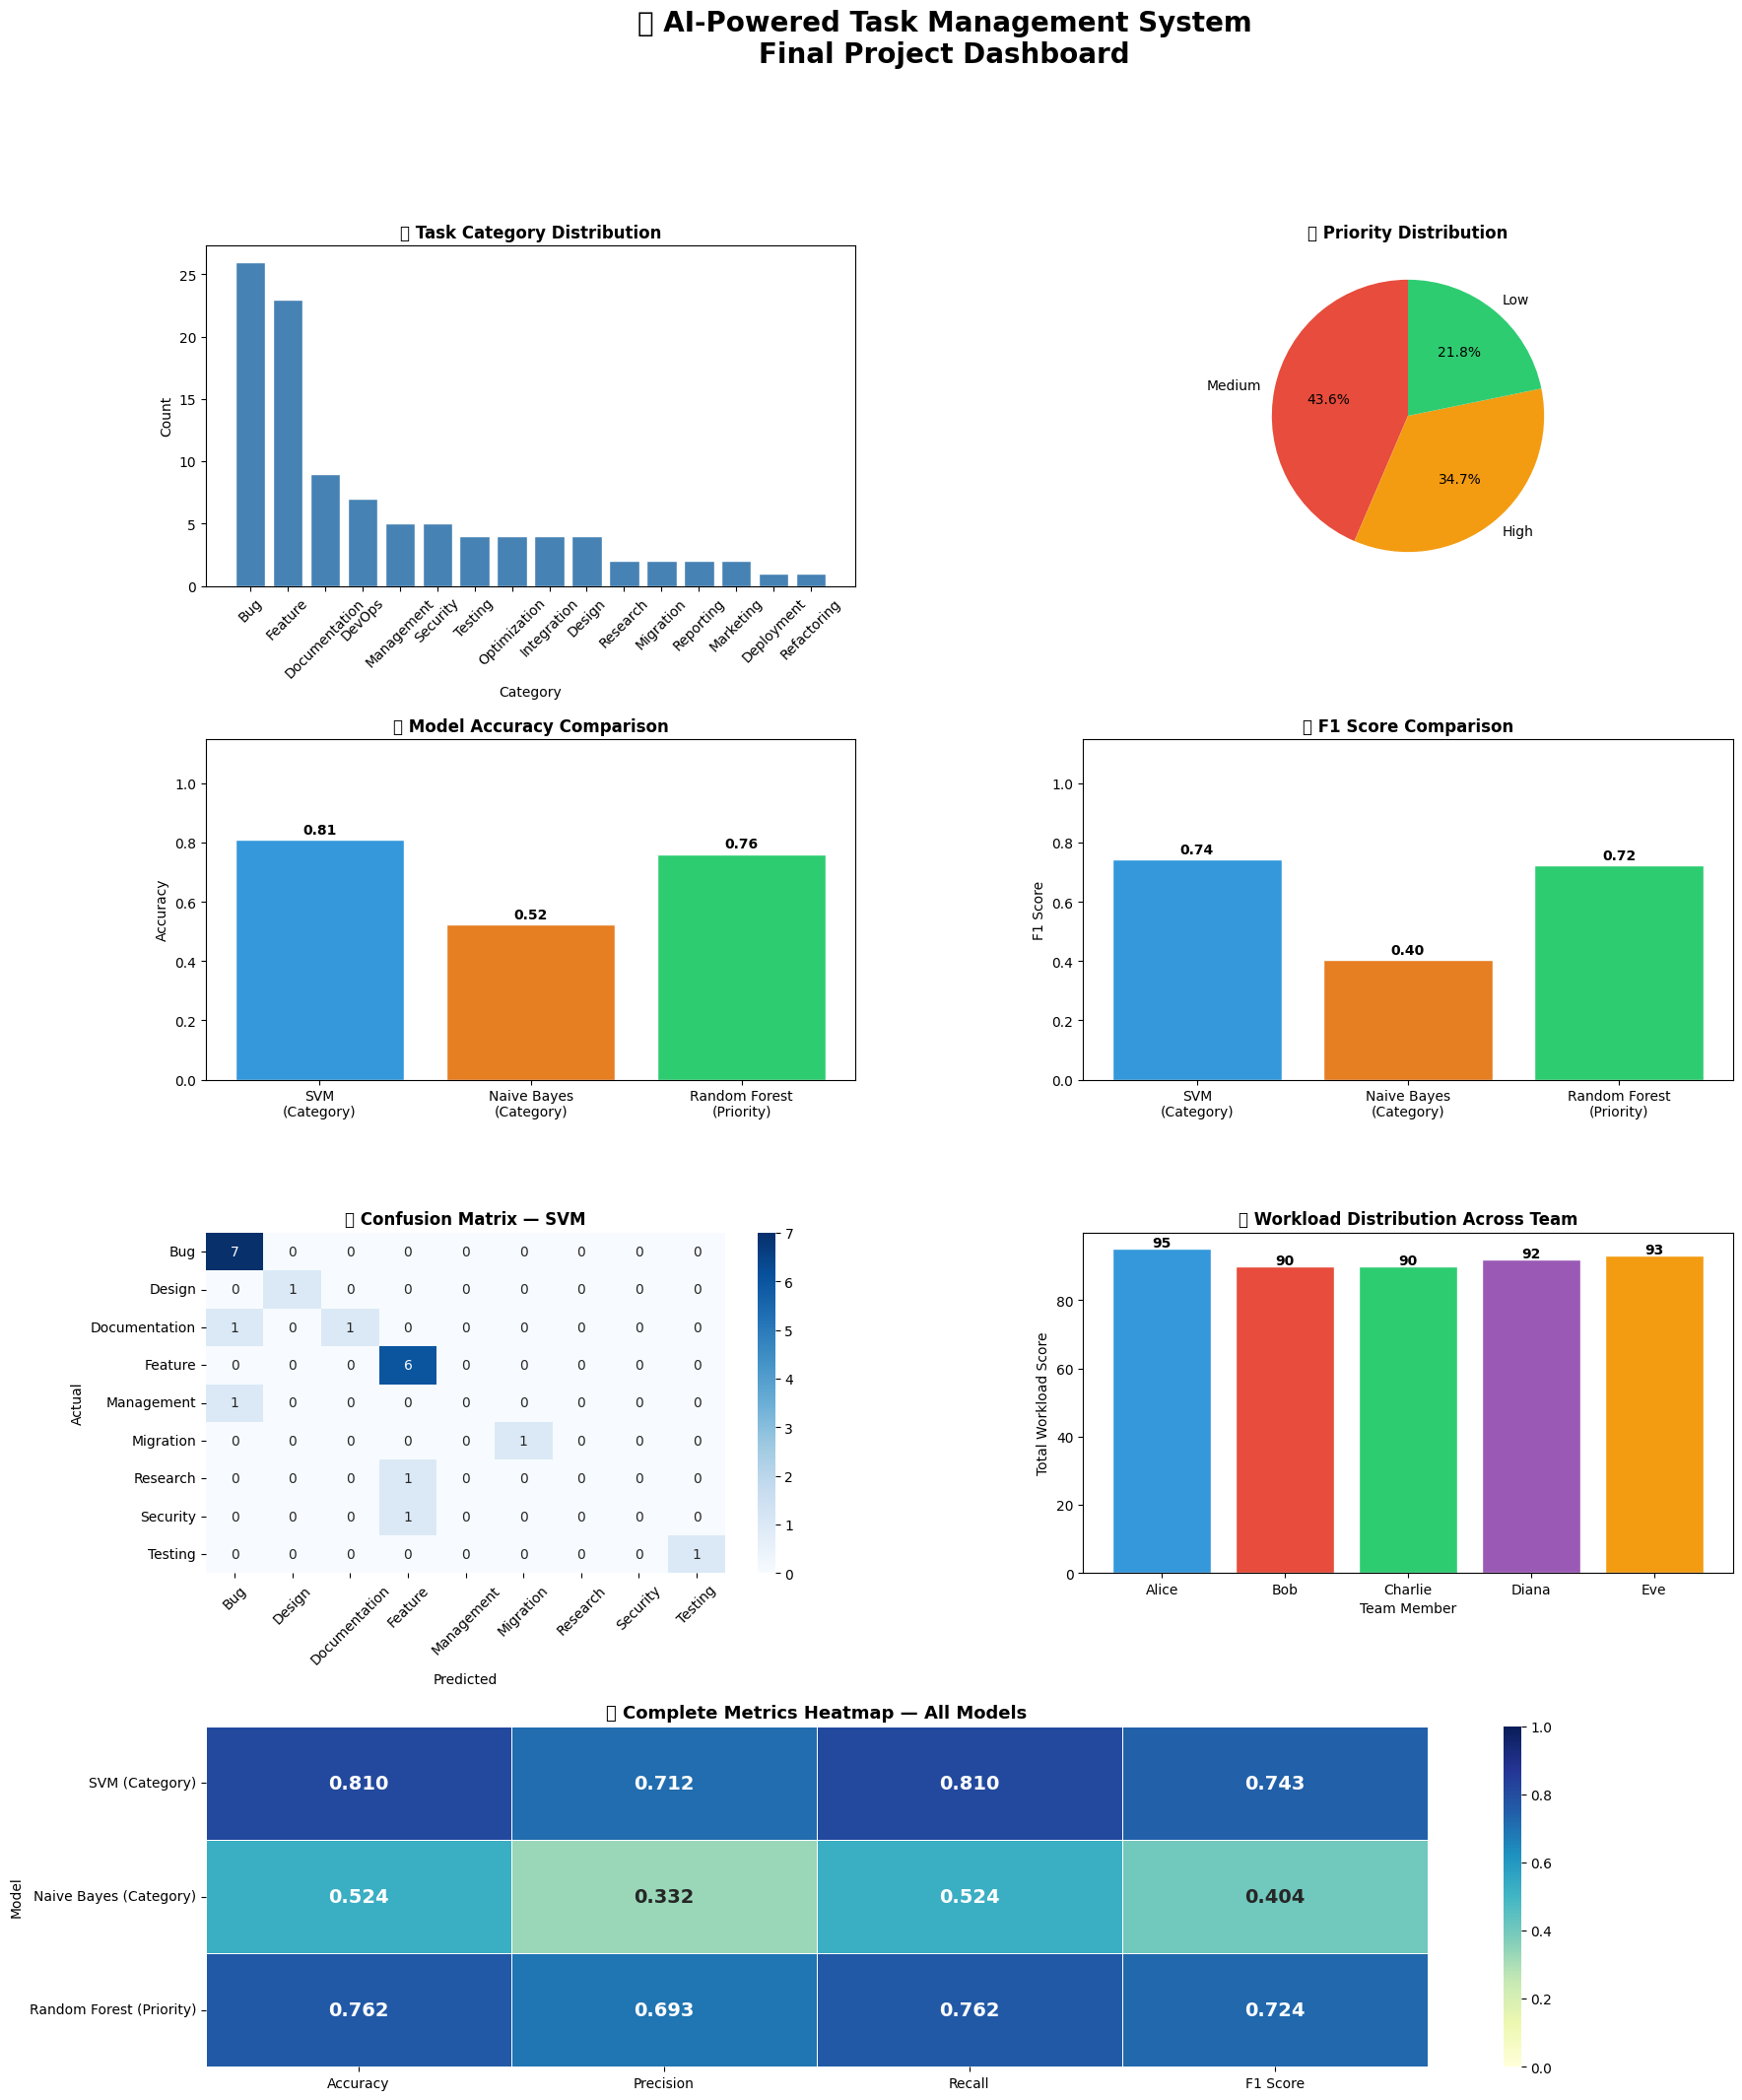

✅ Final dashboard saved as 'final_dashboard.png'


In [37]:
# ============================================================
# PROJECT DASHBOARD — ALL RESULTS IN ONE VIEW
# ============================================================

fig = plt.figure(figsize=(20, 24))
fig.suptitle(
    '🤖 AI-Powered Task Management System\nFinal Project Dashboard',
    fontsize=20, fontweight='bold', y=0.98
)

gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── Plot 1: Category Distribution ──────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
cat_counts = df['category'].value_counts()
ax1.bar(cat_counts.index, cat_counts.values, color='steelblue', edgecolor='white')
ax1.set_title('📂 Task Category Distribution', fontweight='bold')
ax1.set_xlabel('Category')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)

# ── Plot 2: Priority Distribution ──────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
pri_counts = df['priority'].value_counts()
ax2.pie(pri_counts.values, labels=pri_counts.index,
        autopct='%1.1f%%', colors=['#e74c3c','#f39c12','#2ecc71'],
        startangle=90)
ax2.set_title('🎯 Priority Distribution', fontweight='bold')

# ── Plot 3: Model Accuracy Comparison ──────────────────────
ax3 = fig.add_subplot(gs[1, 0])
model_names = ['SVM\n(Category)', 'Naive Bayes\n(Category)', 'Random Forest\n(Priority)']
accuracies  = [metrics_svm['Accuracy'], metrics_nb['Accuracy'], metrics_pri['Accuracy']]
colors      = ['#3498db', '#e67e22', '#2ecc71']
bars = ax3.bar(model_names, accuracies, color=colors, edgecolor='white')
ax3.set_title('🏆 Model Accuracy Comparison', fontweight='bold')
ax3.set_ylabel('Accuracy')
ax3.set_ylim(0, 1.15)
for bar, val in zip(bars, accuracies):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', fontweight='bold')

# ── Plot 4: F1 Score Comparison ────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
f1_scores = [metrics_svm['F1 Score'], metrics_nb['F1 Score'], metrics_pri['F1 Score']]
bars2 = ax4.bar(model_names, f1_scores, color=colors, edgecolor='white')
ax4.set_title('📈 F1 Score Comparison', fontweight='bold')
ax4.set_ylabel('F1 Score')
ax4.set_ylim(0, 1.15)
for bar, val in zip(bars2, f1_scores):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', fontweight='bold')

# ── Plot 5: Confusion Matrix — SVM ─────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
classes_in_test = np.unique(y_test_cat)
class_names     = le.inverse_transform(classes_in_test)
cm_svm = confusion_matrix(y_test_cat, svm_preds, labels=classes_in_test)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax5)
ax5.set_title('🔵 Confusion Matrix — SVM', fontweight='bold')
ax5.set_xlabel('Predicted')
ax5.set_ylabel('Actual')
ax5.tick_params(axis='x', rotation=45)

# ── Plot 6: Workload Distribution ──────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
workload = df.groupby('balanced_assignee')['workload_score'].sum()
ax6.bar(workload.index, workload.values,
        color=['#3498db','#e74c3c','#2ecc71','#9b59b6','#f39c12'],
        edgecolor='white')
ax6.set_title('👥 Workload Distribution Across Team', fontweight='bold')
ax6.set_xlabel('Team Member')
ax6.set_ylabel('Total Workload Score')
for i, v in enumerate(workload.values):
    ax6.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# ── Plot 7: Metrics Heatmap ────────────────────────────────
ax7 = fig.add_subplot(gs[3, :])
metrics_matrix = summary_df.set_index('Model')[['Accuracy','Precision','Recall','F1 Score']]
sns.heatmap(metrics_matrix, annot=True, fmt='.3f', cmap='YlGnBu',
            linewidths=0.5, ax=ax7, vmin=0, vmax=1,
            annot_kws={'size': 14, 'weight': 'bold'})
ax7.set_title('📊 Complete Metrics Heatmap — All Models', fontweight='bold', fontsize=13)
ax7.tick_params(axis='y', rotation=0)

plt.savefig('final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Final dashboard saved as 'final_dashboard.png'")

In [38]:
# ============================================================
# LIVE PREDICTION DEMO
# Give it a new task → it predicts Category + Priority
# ============================================================

import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

stop_words = set(stopwords.words('english'))
stemmer    = PorterStemmer()

def preprocess_text(text):
    text   = text.lower()
    text   = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [stemmer.stem(w) for w in tokens]
    return ' '.join(tokens)

def predict_task(description, deadline_days, workload_score):
    print(f"\n📝 Task        : {description}")
    print(f"⏰ Deadline    : {deadline_days} days")
    print(f"💪 Workload    : {workload_score}/10")
    print("-"*50)

    # Step 1: Predict Category
    cleaned   = preprocess_text(description)
    tfidf_vec = tfidf.transform([cleaned]).toarray()
    cat_pred  = svm_model.predict(tfidf_vec)[0]
    category  = le.inverse_transform([cat_pred])[0]

    # Step 2: Predict Priority
    cat_encoded = category_encoder.transform([category])[0]
    features    = np.array([[cat_encoded, deadline_days, workload_score]])
    pri_pred    = best_priority_model.predict(features)[0]
    priority    = priority_encoder.inverse_transform([pri_pred])[0]

    print(f"🏷️  Category   : {category}")
    print(f"🚨 Priority   : {priority}")
    print("="*50)

# ── Test with sample tasks ──
predict_task("Fix payment button not working on checkout page", 2, 8)
predict_task("Write documentation for the new API endpoints",  10, 3)
predict_task("Set up Docker containers for deployment",        5, 7)
predict_task("Design new landing page for marketing campaign", 14, 5)


📝 Task        : Fix payment button not working on checkout page
⏰ Deadline    : 2 days
💪 Workload    : 8/10
--------------------------------------------------
🏷️  Category   : Bug
🚨 Priority   : Medium

📝 Task        : Write documentation for the new API endpoints
⏰ Deadline    : 10 days
💪 Workload    : 3/10
--------------------------------------------------
🏷️  Category   : Feature
🚨 Priority   : High

📝 Task        : Set up Docker containers for deployment
⏰ Deadline    : 5 days
💪 Workload    : 7/10
--------------------------------------------------
🏷️  Category   : Feature
🚨 Priority   : High

📝 Task        : Design new landing page for marketing campaign
⏰ Deadline    : 14 days
💪 Workload    : 5/10
--------------------------------------------------
🏷️  Category   : Design
🚨 Priority   : Medium


In [39]:
# ============================================================
# FINAL PROJECT SUMMARY REPORT
# ============================================================

print("""
╔══════════════════════════════════════════════════════════════╗
║     🤖 AI-POWERED TASK MANAGEMENT SYSTEM — FINAL REPORT     ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  PROJECT OBJECTIVE                                           ║
║  Automatically classify, prioritize & assign tasks          ║
║  using NLP and Machine Learning techniques.                  ║
║                                                              ║
╠══════════════════════════════════════════════════════════════╣
║  WEEK 1 — Data & NLP                                         ║
║  ✅ 100 tasks dataset created                                ║
║  ✅ EDA with 4 visualizations                                ║
║  ✅ NLP: tokenization, stemming, stopword removal            ║
║  ✅ WordCloud generated                                      ║
╠══════════════════════════════════════════════════════════════╣
║  WEEK 2 — Classification                                     ║
║  ✅ TF-IDF feature extraction (500 features)                 ║
║  ✅ Naive Bayes trained & evaluated                          ║
║  ✅ SVM trained & evaluated                                  ║
║  ✅ Confusion matrices generated                             ║
╠══════════════════════════════════════════════════════════════╣
║  WEEK 3 — Priority & Workload                                ║
║  ✅ Random Forest priority prediction                        ║
║  ✅ XGBoost priority prediction                              ║
║  ✅ Workload balancing logic implemented                     ║
║  ✅ GridSearchCV hyperparameter tuning                       ║
║  ✅ 5-Fold cross validation                                  ║
╠══════════════════════════════════════════════════════════════╣
║  WEEK 4 — Final Dashboard                                    ║
║  ✅ Full project dashboard created                           ║
║  ✅ Live prediction system built                             ║
║  ✅ All models saved                                         ║
╠══════════════════════════════════════════════════════════════╣
║  MODEL PERFORMANCE                                           ║
╚══════════════════════════════════════════════════════════════╝
""")

print(summary_df.to_string(index=False))

print("""
╔══════════════════════════════════════════════════════════════╗
║  TOOLS USED                                                  ║
║  Python, Scikit-learn, XGBoost, NLTK, Pandas, NumPy         ║
║  Matplotlib, Seaborn, Jupyter/Google Colab, GitHub          ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║     🤖 AI-POWERED TASK MANAGEMENT SYSTEM — FINAL REPORT     ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  PROJECT OBJECTIVE                                           ║
║  Automatically classify, prioritize & assign tasks          ║
║  using NLP and Machine Learning techniques.                  ║
║                                                              ║
╠══════════════════════════════════════════════════════════════╣
║  WEEK 1 — Data & NLP                                         ║
║  ✅ 100 tasks dataset created                                ║
║  ✅ EDA with 4 visualizations                                ║
║  ✅ NLP: tokenization, stemming, stopword removal            ║
║  ✅ WordCloud generated                                      ║
╠══════════════════════════════════════════════════════════════╣
║  WEEK 2 — Classification     

In [40]:
# ============================================================
# SAVE FINAL DATASET & CONFIRM ALL FILES
# ============================================================

df.to_csv('task_dataset_FINAL.csv', index=False)

print("✅ All project files saved!")
print("\n📁 FILES GENERATED:")
print("  Datasets  → task_dataset_cleaned.csv")
print("             task_dataset_week2.csv")
print("             task_dataset_week3.csv")
print("             task_dataset_FINAL.csv")
print("\n  Models    → svm_model.pkl")
print("             nb_model.pkl")
print("             best_priority_model.pkl")
print("             tfidf_vectorizer.pkl")
print("             label_encoder.pkl")
print("             priority_encoder.pkl")
print("             category_encoder.pkl")
print("\n  Charts    → eda_visualizations.png")
print("             wordcloud.png")
print("             model_comparison.png")
print("             confusion_matrices.png")
print("             priority_model_comparison.png")
print("             feature_importance.png")
print("             workload_distribution.png")
print("             cross_validation.png")
print("             final_dashboard.png")
print("\n🎉 PROJECT 1 COMPLETE!")

✅ All project files saved!

📁 FILES GENERATED:
  Datasets  → task_dataset_cleaned.csv
             task_dataset_week2.csv
             task_dataset_week3.csv
             task_dataset_FINAL.csv

  Models    → svm_model.pkl
             nb_model.pkl
             best_priority_model.pkl
             tfidf_vectorizer.pkl
             label_encoder.pkl
             priority_encoder.pkl
             category_encoder.pkl

  Charts    → eda_visualizations.png
             wordcloud.png
             model_comparison.png
             confusion_matrices.png
             priority_model_comparison.png
             feature_importance.png
             workload_distribution.png
             cross_validation.png
             final_dashboard.png

🎉 PROJECT 1 COMPLETE!
